In [1]:
import pandas as pd
import os

In [2]:
# Définir le chemin vers le dossier CSV
csv_dir = 'csv'

# Charger tous les fichiers CSV
characters = pd.read_csv(os.path.join(csv_dir, 'characters.csv'))
directors = pd.read_csv(os.path.join(csv_dir, 'directors.csv'))
episodes = pd.read_csv(os.path.join(csv_dir, 'episodes.csv'))
genres = pd.read_csv(os.path.join(csv_dir, 'genres.csv'))
knownformovies = pd.read_csv(os.path.join(csv_dir, 'knownformovies.csv'))
movies = pd.read_csv(os.path.join(csv_dir, 'movies.csv'))
persons = pd.read_csv(os.path.join(csv_dir, 'persons.csv'))
principals = pd.read_csv(os.path.join(csv_dir, 'principals.csv'))
professions = pd.read_csv(os.path.join(csv_dir, 'professions.csv'))
ratings = pd.read_csv(os.path.join(csv_dir, 'ratings.csv'))
titles = pd.read_csv(os.path.join(csv_dir, 'titles.csv'))
writers = pd.read_csv(os.path.join(csv_dir, 'writers.csv'))

print("✓ Tous les fichiers CSV ont été chargés avec succès!")
print(f"\nRésumé des DataFrames chargés:")
print(f"  - characters: {characters.shape}")
print(f"  - directors: {directors.shape}")
print(f"  - episodes: {episodes.shape}")
print(f"  - genres: {genres.shape}")
print(f"  - knownformovies: {knownformovies.shape}")
print(f"  - movies: {movies.shape}")
print(f"  - persons: {persons.shape}")
print(f"  - principals: {principals.shape}")
print(f"  - professions: {professions.shape}")
print(f"  - ratings: {ratings.shape}")
print(f"  - titles: {titles.shape}")
print(f"  - writers: {writers.shape}")

✓ Tous les fichiers CSV ont été chargés avec succès!

Résumé des DataFrames chargés:
  - characters: (1405274, 3)
  - directors: (419861, 2)
  - episodes: (115576, 4)
  - genres: (649379, 2)
  - knownformovies: (1328773, 2)
  - movies: (291238, 8)
  - persons: (632324, 4)
  - principals: (2745688, 5)
  - professions: (1231760, 2)
  - ratings: (291238, 3)
  - titles: (1908072, 8)
  - writers: (900485, 2)


# 2. Statistiques descriptives pour chaque fichier

In [ ]:
# Fonction pour afficher les statistiques descriptives
def afficher_stats(nom_df, df):
    print(f"\n{'='*60}")
    print(f"📊 {nom_df.upper()}")
    print(f"Format: {df.shape[0]} lignes × {df.shape[1]} colonnes")
    print(f"\nTypes de données:")
    print(df.dtypes)
    print(f"\nValeurs manquantes:")
    missing = df.isnull().sum()
    print(f"{missing} valeurs manquantes")
    print(f"\nValeurs uniques par colonne:")
    for col in df.columns:
        print(f"  {col}: {df[col].nunique()} uniques")

# Appliquer à tous les DataFrames
dfs = {
    'characters': characters,
    'directors': directors,
    'episodes': episodes,
    'genres': genres,
    'knownformovies': knownformovies,
    'movies': movies,
    'persons': persons,
    'principals': principals,
    'professions': professions,
    'ratings': ratings,
    'titles': titles,
    'writers': writers
}

for nom, df in dfs.items():
    afficher_stats(nom, df)


📊 CHARACTERS
Format: 1405274 lignes × 3 colonnes

Types de données:
('mid',)     object
('pid',)     object
('name',)    object
dtype: object

Valeurs manquantes:
('mid',)     0
('pid',)     0
('name',)    1
dtype: int64 valeurs manquantes

Valeurs uniques par colonne:
  ('mid',): 282474 uniques
  ('pid',): 296694 uniques
  ('name',): 496806 uniques

📊 DIRECTORS
Format: 419861 lignes × 2 colonnes

Types de données:
('mid',)    object
('pid',)    object
dtype: object

Valeurs manquantes:
('mid',)    0
('pid',)    0
dtype: int64 valeurs manquantes

Valeurs uniques par colonne:
  ('mid',): 279440 uniques
  ('pid',): 89307 uniques

📊 EPISODES
Format: 115576 lignes × 4 colonnes

Types de données:
('mid',)               object
('parentMid',)         object
('seasonNumber',)     float64
('episodeNumber',)    float64
dtype: object

Valeurs manquantes:
('mid',)                0
('parentMid',)          0
('seasonNumber',)     628
('episodeNumber',)    628
dtype: int64 valeurs manquantes

Valeur

# 3. Analyses exploratoires

3.1 - Distribution des films par année
Colonnes de 'movies': ["('mid',)", "('titleType',)", "('primaryTitle',)", "('originalTitle',)", "('isAdult',)", "('startYear',)", "('endYear',)", "('runtimeMinutes',)"]


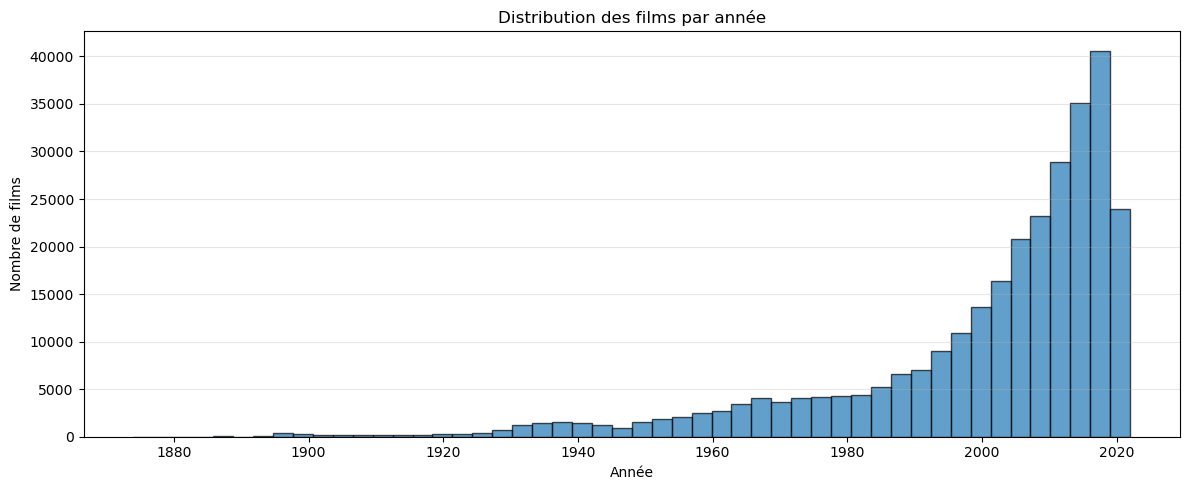

Nombre de films avec année valide: 291238
Année min: 1874, Année max: 2022


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd 

# 3.1 - Distribution des films par année (histogramme)
print("=" * 60)
print("3.1 - Distribution des films par année")

# Vérifier les colonnes de 'movies' pour trouver l'année
print(f"Colonnes de 'movies': {movies.columns.tolist()}")

if "('startYear',)" in movies.columns:
    # Filtrer les années valides (convertir en numérique, exclure null et 'N/A')
    years = pd.to_numeric(movies["('startYear',)"], errors='coerce')
    years = years[years.notna() & (years > 1800) & (years <= 2025)]
    
    plt.figure(figsize=(12, 5))
    plt.hist(years, bins=50, edgecolor='black', alpha=0.7)
    plt.xlabel('Année')
    plt.ylabel('Nombre de films')
    plt.title('Distribution des films par année')
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    print(f"Nombre de films avec année valide: {len(years)}")
    print(f"Année min: {years.min()}, Année max: {years.max()}")
else:
    print("Colonne 'startYear' non trouvée dans 'movies'")


3.2 - Top 10 des genres les plus fréquents
Colonnes de 'genres': ["('mid',)", "('genre',)"]

Top 10 des genres:
('genre',)
Drama        138499
Comedy       100811
Action        55128
Crime         46429
Adventure     42797
Animation     34917
Romance       32335
Mystery       25319
Thriller      22224
Family        20703
Name: count, dtype: int64


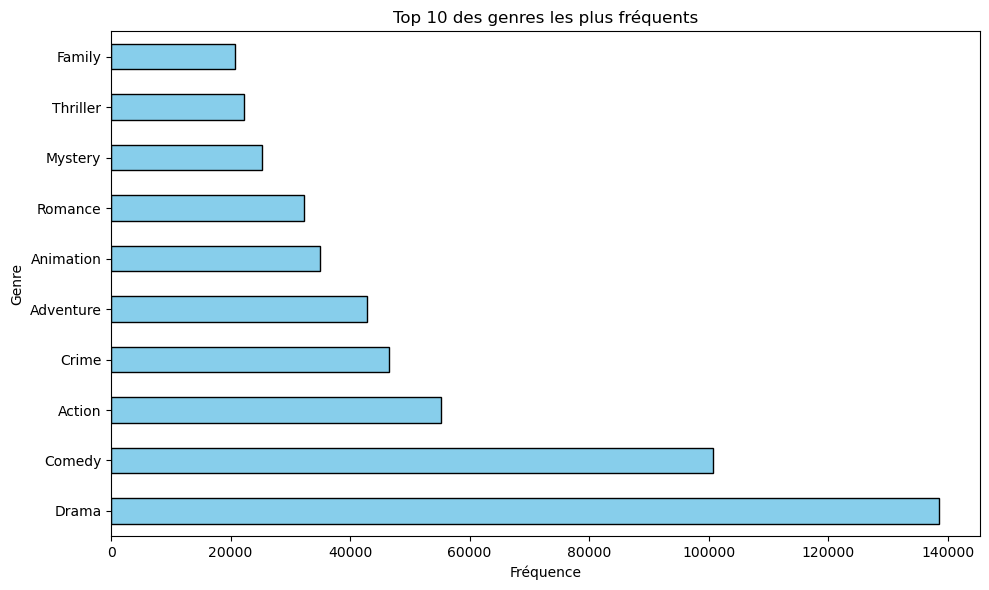

In [5]:
# 3.2 - Top 10 des genres les plus fréquents
print("\n" + "=" * 60)
print("3.2 - Top 10 des genres les plus fréquents")
print("=" * 60)

# Vérifier les colonnes de 'genres'
print(f"Colonnes de 'genres': {genres.columns.tolist()}")

if "('genre',)" in genres.columns:
    top_genres = genres["('genre',)"].value_counts().head(10)
    print(f"\nTop 10 des genres:")
    print(top_genres)
    
    plt.figure(figsize=(10, 6))
    top_genres.plot(kind='barh', color='skyblue', edgecolor='black')
    plt.xlabel('Fréquence')
    plt.ylabel('Genre')
    plt.title('Top 10 des genres les plus fréquents')
    plt.tight_layout()
    plt.show()
else:
    print("Colonne ('genre',) non trouvée dans 'genres'")


3.3 - Distribution des notes (ratings)
Colonnes de 'ratings': ["('mid',)", "('averageRating',)", "('numVotes',)"]

Statistiques des notes:
count    291238.000000
mean          6.832635
std           1.400024
min           1.000000
25%           6.100000
50%           7.100000
75%           7.800000
max          10.000000
Name: ('averageRating',), dtype: float64


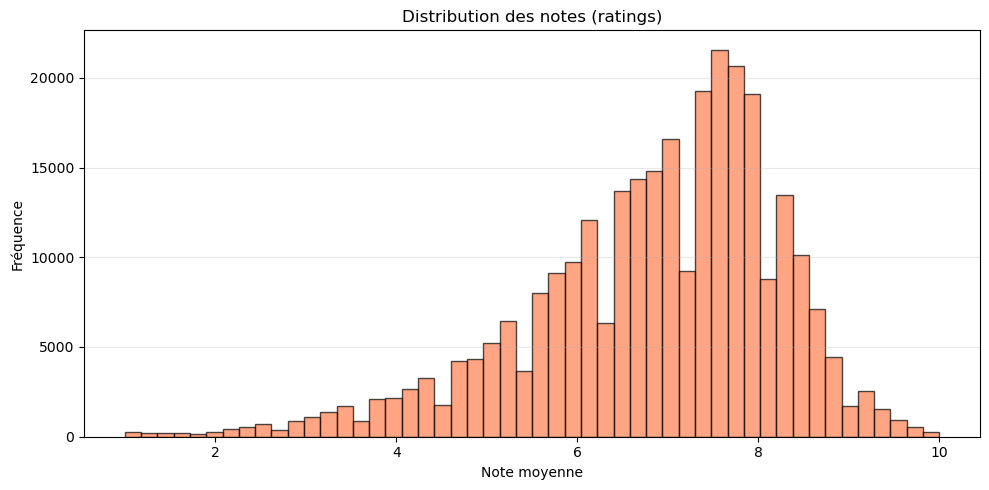

In [6]:
# 3.3 - Distribution des notes (ratings)
print("\n" + "=" * 60)
print("3.3 - Distribution des notes (ratings)")

print(f"Colonnes de 'ratings': {ratings.columns.tolist()}")

if "('averageRating',)" in ratings.columns:
    rating_values = pd.to_numeric(ratings["('averageRating',)"], errors='coerce')
    rating_values = rating_values[rating_values.notna()]
    
    print(f"\nStatistiques des notes:")
    print(rating_values.describe())
    
    plt.figure(figsize=(10, 5))
    plt.hist(rating_values, bins=50, edgecolor='black', alpha=0.7, color='coral')
    plt.xlabel('Note moyenne')
    plt.ylabel('Fréquence')
    plt.title('Distribution des notes (ratings)')
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("Colonne ('averageRating',) non trouvée dans 'ratings'")


3.4 - Nombre moyen d'acteurs par film

Statistiques du nombre d'acteurs par film:
count    290668.000000
mean          9.446131
std           1.599951
min           1.000000
25%          10.000000
50%          10.000000
75%          10.000000
max          10.000000
dtype: float64


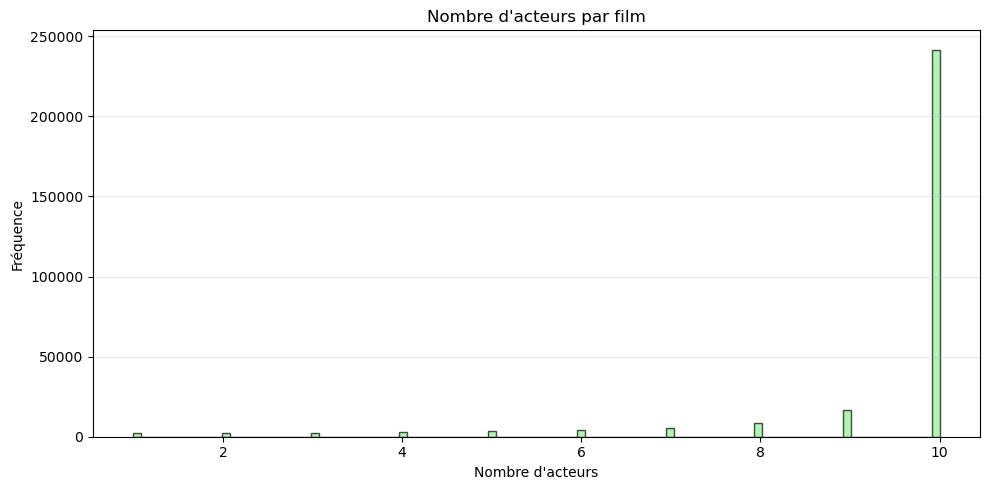


Nombre moyen d'acteurs par film: 9.45


In [7]:
# 3.4 - Nombre moyen d'acteurs par film
print("\n" + "=" * 60)
print("3.4 - Nombre moyen d'acteurs par film")

# Compter le nombre d'acteurs par film
if "('mid',)" in principals.columns:
    actors_per_movie = principals.groupby("('mid',)").size()
    print(f"\nStatistiques du nombre d'acteurs par film:")
    print(actors_per_movie.describe())
    
    plt.figure(figsize=(10, 5))
    plt.hist(actors_per_movie, bins=100, edgecolor='black', alpha=0.7, color='lightgreen')
    plt.xlabel('Nombre d\'acteurs')
    plt.ylabel('Fréquence')
    plt.title('Nombre d\'acteurs par film')
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    print(f"\nNombre moyen d'acteurs par film: {actors_per_movie.mean():.2f}")
else:
    print("Colonne ('mid',) non trouvée dans 'principals'")

# 4. Relations entre tables

In [8]:
# Liste de tous les identifiants de titres valides (Clé Primaire)
valid_mids = set(persons["('pid',)"])

# Dictionnaire pour stocker les résultats d'orphelinat
orphan_results = {}

valid_mids = set(movies["('mid',)"])
valid_pids = set(persons["('pid',)"])
for key, value in dfs.items():
    try:
        current_mids = set(value["('mid',)"])
        orphan_mids = current_mids - valid_mids
        if len(orphan_mids) != 0:
            print(f"Table '{key}', mid :")
            print(f"   Nombre d'orphelins trouvés : {len(orphan_mids)}")
            print()
    except:
        pass
    try:
        current_mids = set(value["('parentMid',)"])
        orphan_mids = current_mids - valid_mids
        if len(orphan_mids) != 0:
            print(f"Table '{key}', parentMid :")
            print(f"   Nombre d'orphelins trouvés : {len(orphan_mids)}")
            print()
    except:
        pass
    try:
        current_pids = set(value["('pid',)"])
        orphan_pids = current_pids - valid_pids
        if len(orphan_pids) != 0:
            print(f"Table '{key}', pid :")
            print(f"   Nombre d'orphelins trouvés : {len(orphan_pids)}")
            print()
    except:
        pass

Table 'characters', pid :
   Nombre d'orphelins trouvés : 321

Table 'directors', pid :
   Nombre d'orphelins trouvés : 2

Table 'episodes', parentMid :
   Nombre d'orphelins trouvés : 184

Table 'principals', pid :
   Nombre d'orphelins trouvés : 367

Table 'writers', pid :
   Nombre d'orphelins trouvés : 13

